In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import corner

def get_paras_chain(path, para_name='para'):
    pars = np.loadtxt(f'{path}/pars.txt',dtype=str)
    par_idx = np.where(np.char.find(pars, f'{para_name}') != -1)[0]
    par_chain = np.loadtxt(f'{path}/chain_1.txt',usecols=par_idx)
    return par_chain



In [ ]:
draws = []
burnin = int(1.8e5)

path = ''

for i in range(28):

    gw_rho = f'gw_log10_rho_{i}'
    
    gw_rho_chain = get_paras_chain(path, para_name=gw_rho)

    gw_rho_chain = gw_rho_chain[burnin:]

    draws.append(gw_rho_chain)


In [ ]:


Tspan = (59645 - 53040)*86400
components = 28
freqs = 1.0*np.arange(1.0, components + 1, 1.0)/Tspan

freqs = np.log10(freqs)
bin_widths = np.diff(freqs)
bin_widths = np.append(bin_widths, bin_widths[-1])

In [ ]:
plt.rcParams.update({
    # LaTeX相关设置
    "text.usetex": True,                # 必须启用LaTeX
    "text.latex.preamble": r"""
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage{amsfonts}
    \usepackage{bm}
    """, # 数学符号支持
    "font.family": "serif",             # 强制使用衬线字体
    "font.serif": ["Times New Roman"],  # APS推荐字体
    "mathtext.fontset": "stix",         # 数学字体与正文匹配


    "figure.dpi": 600,                  # 出版级分辨率
    
    # 坐标轴参数
    "axes.labelsize": 16,                # 略微缩小标签字号
    "axes.linewidth": 1.3,              # 坐标轴线宽加粗
    
    # 刻度参数
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.width": 1,           # 刻度线加粗
    "ytick.major.width": 1,
    
    # 图例参数
    "legend.fontsize": 14,
    "legend.frameon": True,            # 去除图例边框
    
    "errorbar.capsize": 3               # 误差线端帽尺寸
}) 

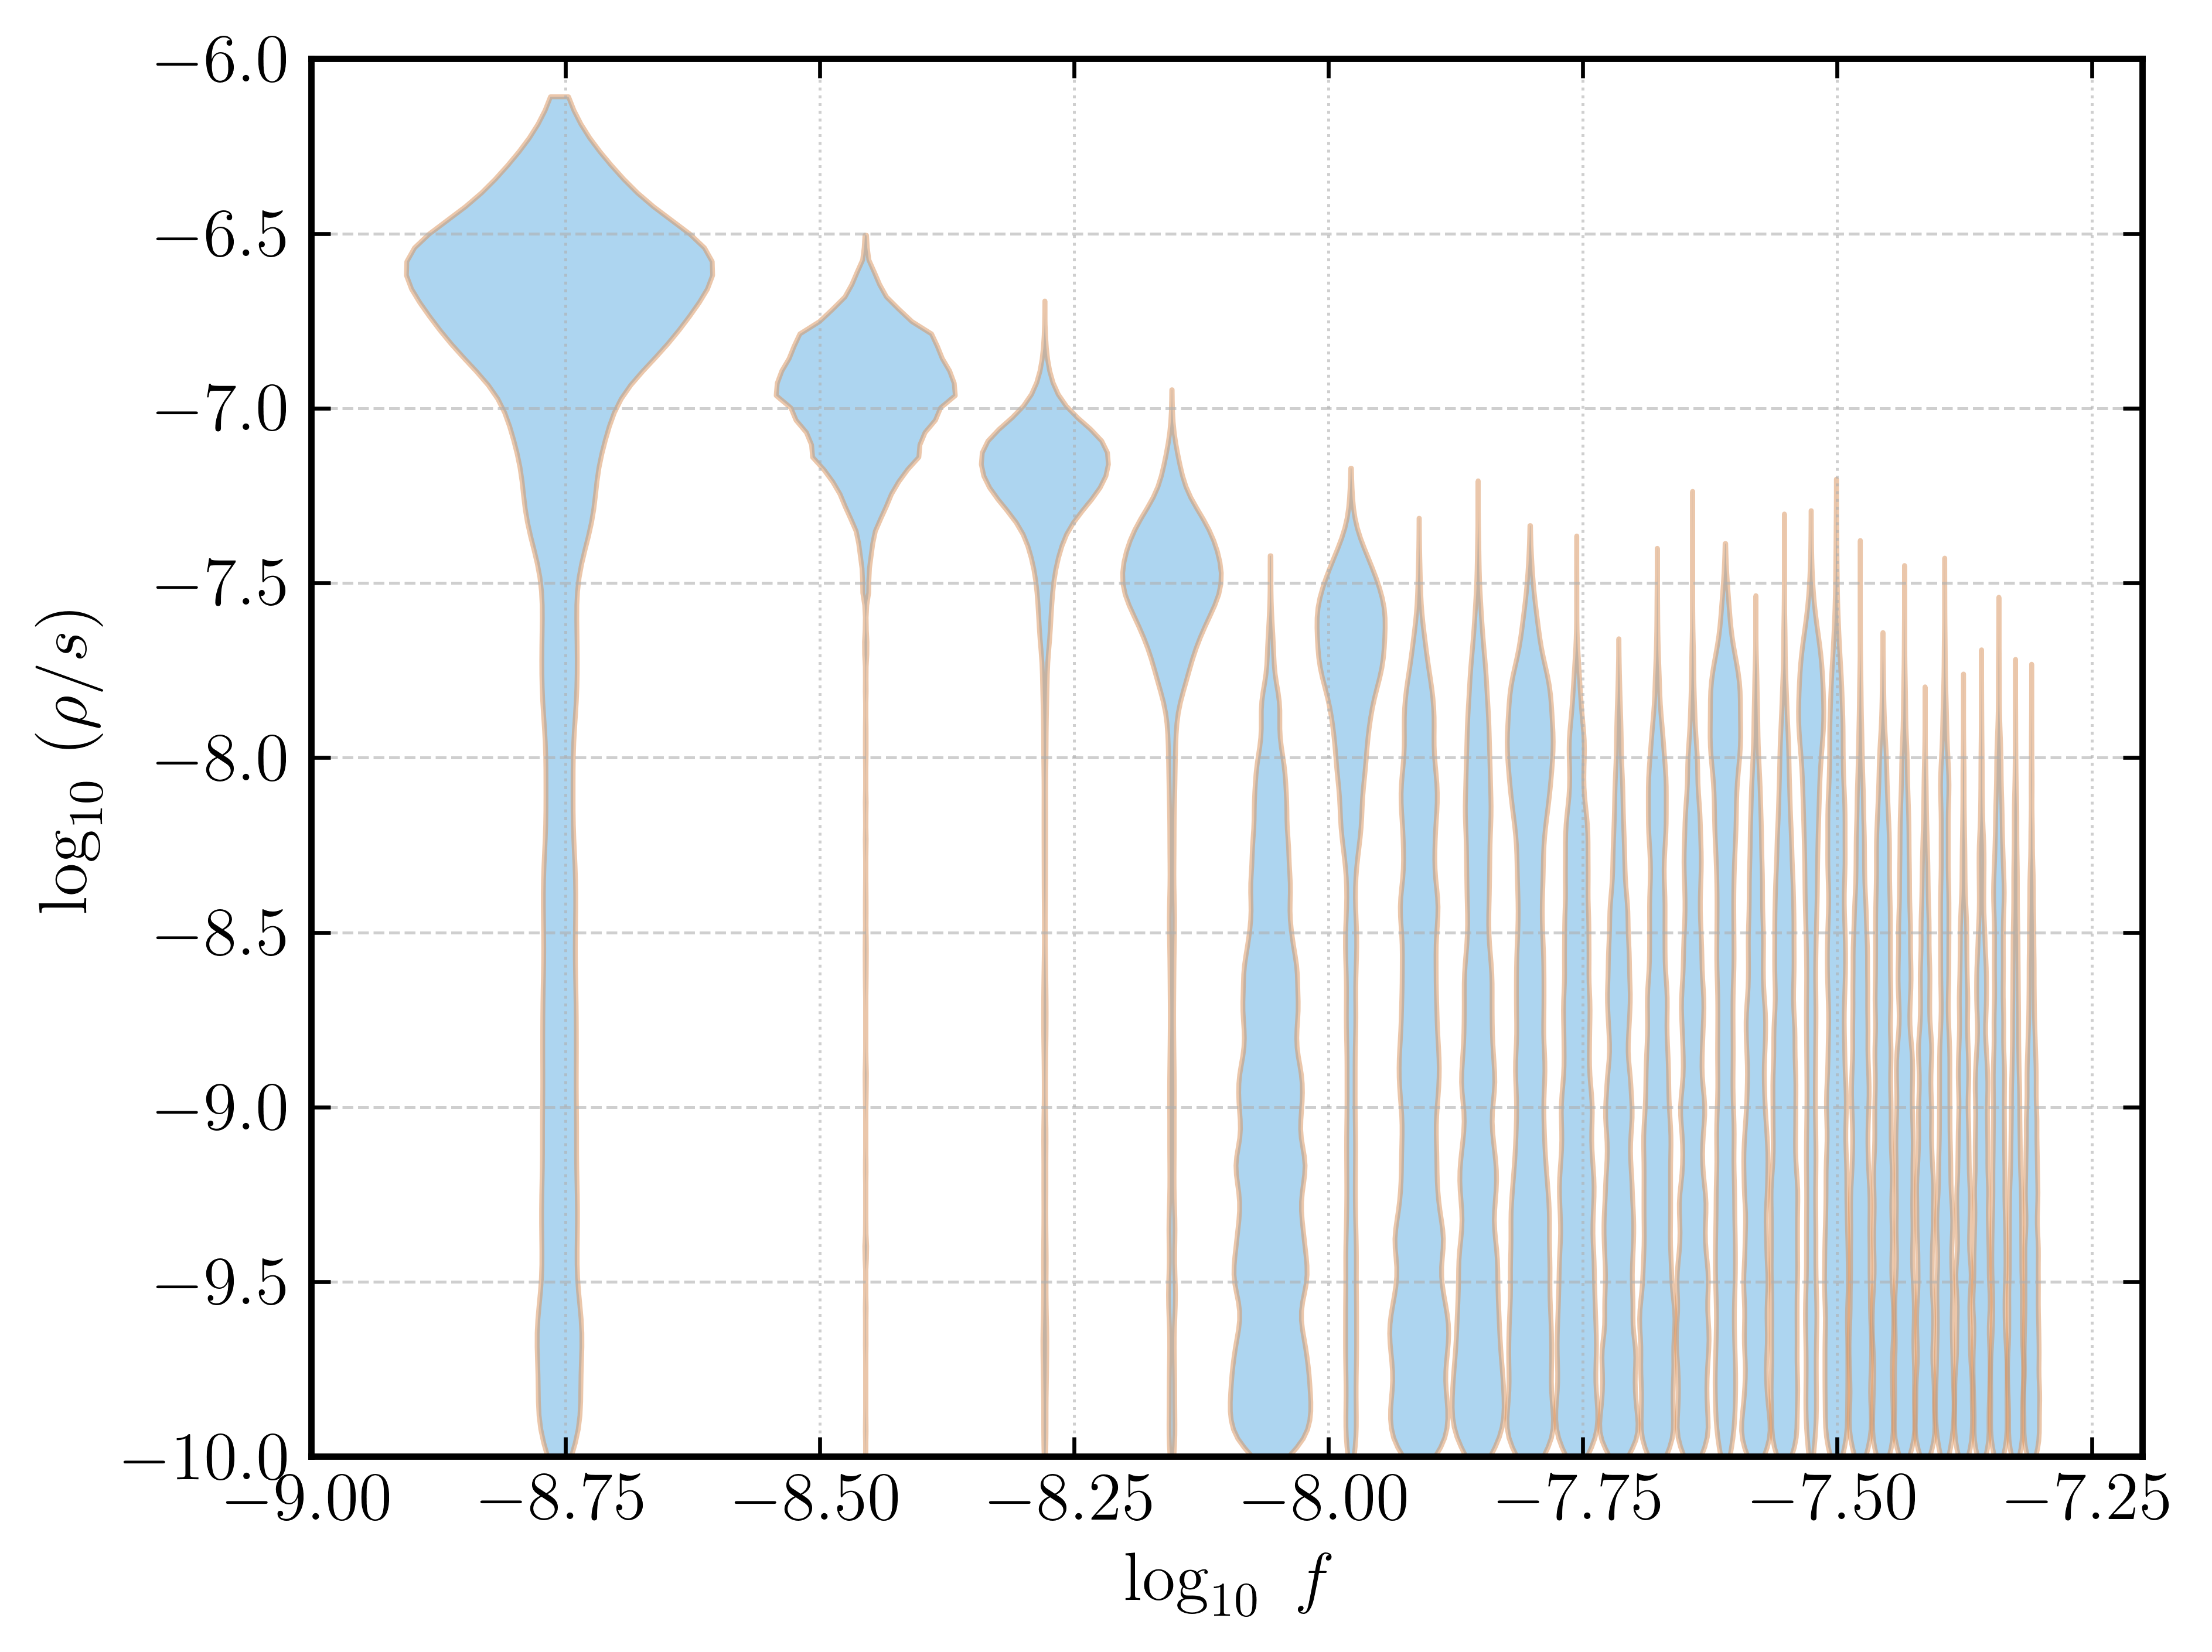

In [ ]:
parts = plt.violinplot(dataset=draws, positions=freqs, showextrema = False, showmeans = False, showmedians = False, widths = bin_widths)


for pc in parts['bodies']:
    pc.set_facecolor('#5DADE2')
    pc.set_edgecolor('#D99058')
    pc.set_alpha(0.5)


plt.grid(True, which='both', axis='x', linestyle=':', linewidth=0.6, alpha=0.6)
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.6, alpha=0.6)


plt.xlim(-9,-7.2)
plt.ylim(-10,-6)

plt.ylabel(r'$\log_{10} \ (\rho/s)$')
plt.xlabel(r'$\log_{10} \ f$')

plt.tick_params(which='major', axis='both',direction='in', length=4, width=0.8, bottom=True, top=True, left=True, right=True)
plt.tick_params(which='minor',axis='both', direction='in', length=2, width=0.6, bottom=True, top=True, left=True, right=True)
plt.tight_layout()


plt.show()

